# Netflix EDA Project
TODO -> import libraries
TODO ->Talk about the datset
TODO -> Understanding the dataset 

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preparation and Cleaning
-> Loading file using pandas
-> Looking at the information about the data and columns
 

In [41]:
df = pd.read_csv('D:/Python/Projects/Netflix_EDA_Project/netflix_titles.csv', encoding='latin-1')
df.head()
df.info()



<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [42]:
#Check for missing values and get basic statistics
df.isnull().sum()
df.describe()


,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [43]:
#Fill missing values in 'director', 'cast', and 'country' columns with 'Unknown'
df['director'] = df['director'].fillna('Unknown',inplace=True)
df['cast'] = df['cast'].fillna('Unknown',inplace=True)
df['country'] = df['country'].fillna('Unknown',inplace=True)

C:\Users\dell\AppData\Local\Temp\ipykernel_16420\2480312649.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['director'] = df['director'].fillna('Unknown',inplace=True)
C:\Users\dell\AppData\Local\Temp\ipykernel_16420\2480312649.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chaine

In [44]:
#Drop rows with missing values in 'date_added', 'rating', and 'duration' columns
df.dropna(subset=['date_added'],inplace=True)
df.dropna(subset=['rating'],inplace=True)
df.dropna(subset=['duration'],inplace=True)
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

# Visualization

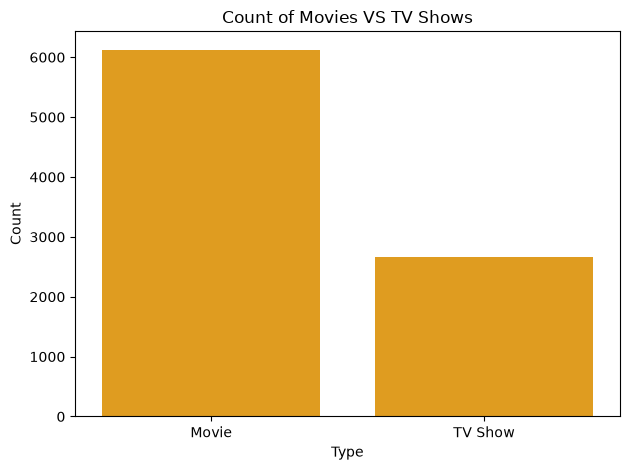

In [53]:
#count of movies vs tv shows
sns.countplot(x='type',data=df,color='orange')
plt.title('Count of Movies VS TV Shows')
plt.xlabel('Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()



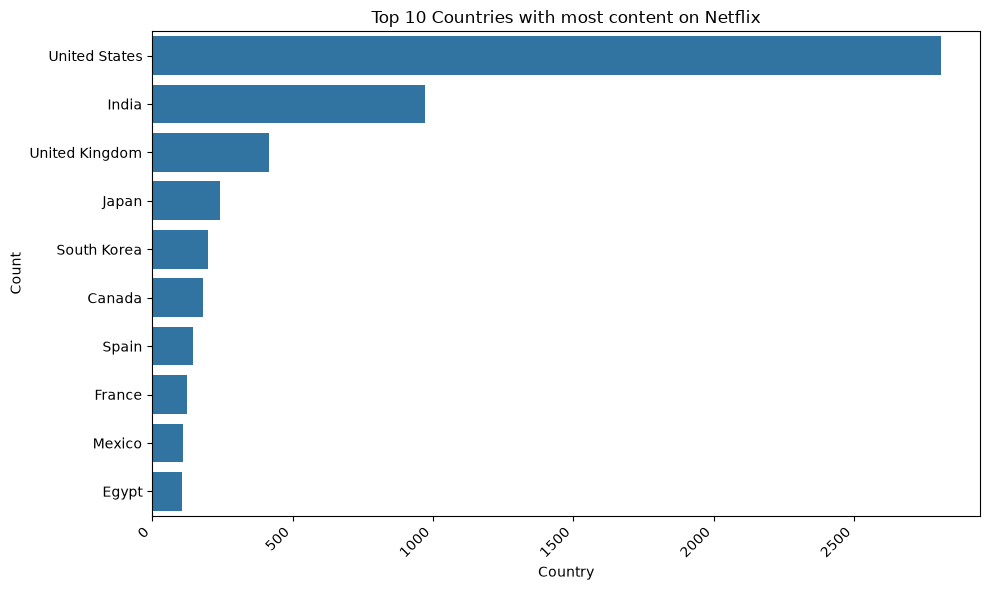

In [46]:
#Top 10 Countries with most content on Netflix
plt.figure(figsize=(10, 6))

top10 = df[df['country'] != 'Unknown']['country'].value_counts().head(10)
sns.barplot(x=top10.values, y=top10.index)

plt.xlabel('Country')
plt.ylabel('Count')
plt.title('Top 10 Countries with most content on Netflix')

plt.xticks(rotation=45, ha='right')  

plt.tight_layout()
plt.show()
              

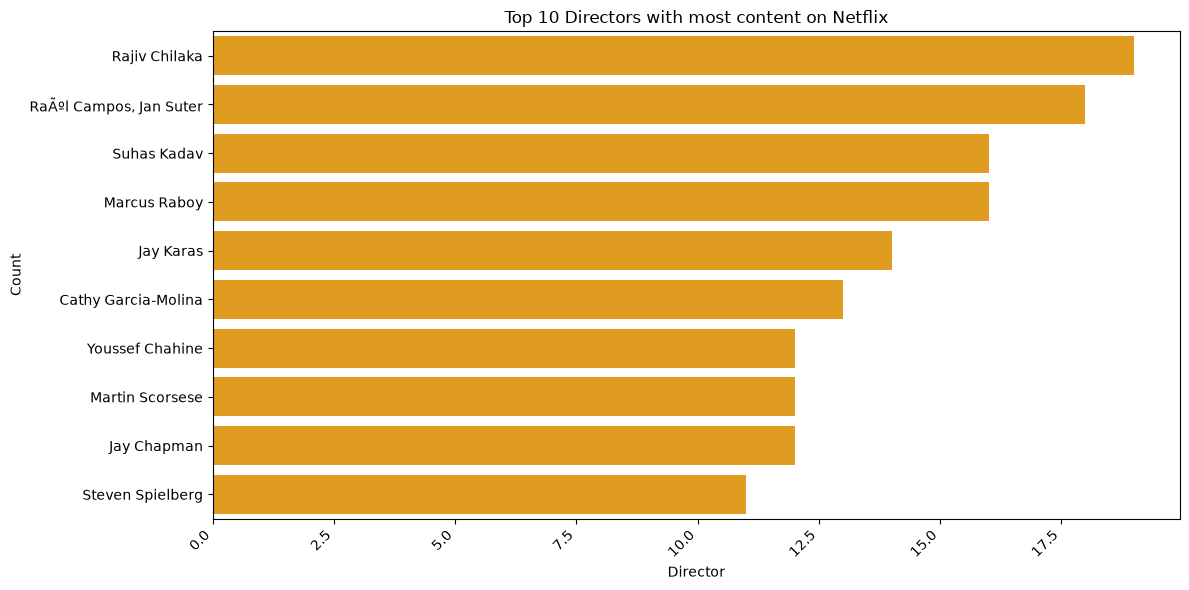

In [49]:
#Top 10 directors with most content on Netflix
top10 = df[df['director'] != 'Unknown']['director'].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(x=top10.values, y=top10.index,color='orange')

plt.xlabel('Director')
plt.ylabel('Count')
plt.title('Top 10 Directors with most content on Netflix')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

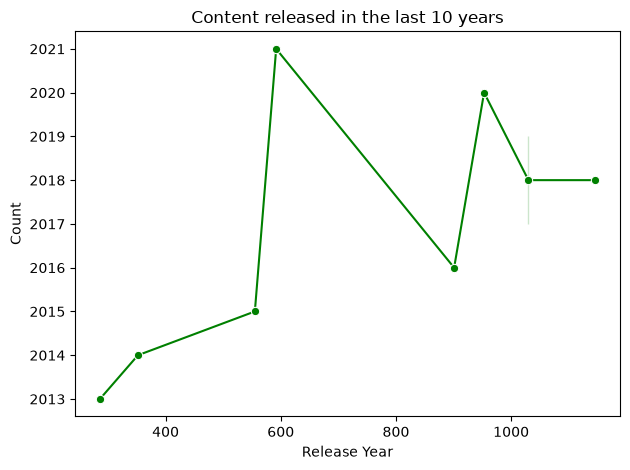

In [50]:
#Content released in the last 10 years
last_ten_years = df[df['release_year'] >= 2013]['release_year'].value_counts().sort_index()
sns.lineplot(x=last_ten_years.values, y=last_ten_years.index, marker='o', color='green')
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.title('Content released in the last 10 years')
plt.tight_layout()
plt.show()

In [51]:
df.to_csv('D:/Python/Projects/Netflix_EDA_Project/netflix_titles_cleaned.csv', index=False)